## Adding the isSignal column

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df1 = root_pandas.read_root('../exp16_17_e_idglobal_bb_2/exp16_17_e_all_0.root',key='B0')

Welcome to JupyROOT 6.24/06


In [2]:
df1['isSignal']=0.0

In [3]:
df1.to_root('exp16_17_e_all.root',key='B0')

/cvmfs/belle.cern.ch/el7/externals/v01-11-00/Linux_x86_64/common/lib/python3.8/site-packages/root_numpy/_tree.py:575: UserWarning: converter for dtype('O') is not implemented (skipping)
  cobj = _librootnumpy.array2tree_toCObj(arr, name=name, tree=incobj)


In [3]:
df3.isna().any(axis=0)

__experiment__          False
__run__                 False
__event__               False
__production__          False
__candidate__           False
                        ...  
tag_nDaughterPhotons    False
DecayMode               False
MM2                     False
cos_D_l                 False
Signal                  False
Length: 255, dtype: bool

In [9]:
columns_nan = df3.columns[df3.isna().any(axis=0)]
columns_nan

Index(['B0_isSignal', 'B0_mcPDG', 'B0_DecayHash', 'B0_DecayHashEx',
       'B0_roeMC_E', 'B0_roeMC_M', 'B0_roeMC_P', 'B0_roeMC_PTheta',
       'B0_roeMC_Pt', 'B0_roeMC_Px', 'B0_roeMC_Py', 'B0_roeMC_Pz',
       'B0_CMS_roeMC_E', 'B0_CMS_roeMC_M', 'B0_CMS_roeMC_P',
       'B0_CMS_roeMC_PTheta', 'B0_CMS_roeMC_Pt', 'B0_CMS_roeMC_Px',
       'B0_CMS_roeMC_Py', 'B0_CMS_roeMC_Pz', 'B0_DeltaT', 'B0_DeltaTErr',
       'B0_DeltaZ', 'B0_DeltaBoost', 'B0_DeltaBoostErr', 'B0_TagVLBoost',
       'B0_TagVLBoostErr', 'B0_TagVOBoost', 'B0_TagVOBoostErr', 'B0_TagVx',
       'B0_TagVy', 'B0_TagVyErr', 'B0_TagVz', 'B0_mcDeltaTau', 'B0_mcDeltaT',
       'B0_mcDeltaBoost', 'B0_mcTagVLBoost', 'B0_mcTagVOBoost', 'B0_mcLBoost',
       'B0_mcOBoost', 'B0_mcTagVx', 'B0_mcTagVy', 'B0_mcTagVz', 'D_isSignal',
       'D_mcPDG', 'e_ErrM', 'e_SigM', 'e_isSignal', 'e_mcPDG'],
      dtype='object')

In [34]:
pandas.set_option('display.max_rows', None)
print(df3.isna().sum())

__experiment__                            0
__run__                                   0
__event__                                 0
__production__                            0
__candidate__                             0
__ncandidates__                           0
__weight__                                0
Ecms                                      0
IPX                                       0
IPY                                       0
IPZ                                       0
missingMomentumOfEvent                    0
missingMomentumOfEvent_Px                 0
missingMomentumOfEvent_Py                 0
missingMomentumOfEvent_Pz                 0
missingMomentumOfEvent_theta              0
missingMomentumOfEventCMS                 0
missingMomentumOfEventCMS_Px              0
missingMomentumOfEventCMS_Py              0
missingMomentumOfEventCMS_Pz              0
missingMomentumOfEventCMS_theta           0
missingEnergyOfEventCMS                   0
missingMass2OfEvent             

In [35]:
df3.DecayMode.value_counts()

bkg                 35325
sig_D_tau_nu        25097
all_Dstst_e_nu      12413
all_Dst_e_nu         9447
sig_D_e_nu           1137
all_Dstst_tau_nu      660
all_Dstst_mu_nu       518
all_Dst_tau_nu        436
all_Dst_mu_nu         376
sig_D_mu_nu           102
Name: DecayMode, dtype: int64

## grid search result

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df2 = pandas.read_csv('MVA1_5/MVA1_5_grid_search_result_1.csv')
df2.eval('diff_train_test_sklearn = training_auc_sklearn - test_auc_sklearn', inplace=True)
df3 = pandas.read_csv('MVA2/MVA2_1_grid_search_result_1.csv')
df3.eval('diff_train_test_sklearn = training_auc_sklearn - test_auc_sklearn', inplace=True)

In [13]:
df2.query('diff_train_test_sklearn<0.004').describe()

,Unnamed: 0,nTrees,depth,learning_rate,nCutLevels,sub_sampling_rate,training_auc_basf2,training_auc_sklearn,test_auc_basf2,test_auc_sklearn,diff_train_test_sklearn
count,23.000000,23.000000,23.0,23.000000,23.000000,23.0,23.000000,23.000000,23.000000,23.000000,23.000000
mean,32.130435,1486.956522,2.0,0.058696,4.826087,0.5,0.927224,0.927229,0.923593,0.923611,0.003618
std,25.708690,81.488135,0.0,0.010137,0.984063,0.0,0.000873,0.000873,0.000651,0.000651,0.000262
min,0.000000,1400.000000,2.0,0.050000,4.000000,0.5,0.925333,0.925338,0.922193,0.922211,0.003127
25%,6.500000,1400.000000,2.0,0.050000,4.000000,0.5,0.926702,0.926707,0.923230,0.923248,0.003447
50%,34.000000,1500.000000,2.0,0.060000,5.000000,0.5,0.927364,0.927368,0.923675,0.923693,0.003670
75%,54.000000,1550.000000,2.0,0.065000,5.000000,0.5,0.927763,0.927768,0.924018,0.924036,0.003818
max,72.000000,1600.000000,2.0,0.080000,7.000000,0.5,0.928656,0.928660,0.924801,0.924819,0.003998


In [15]:
df2.query('diff_train_test_sklearn<0.004 and test_auc_sklearn>0.924')

,Unnamed: 0,nTrees,depth,learning_rate,nCutLevels,sub_sampling_rate,training_auc_basf2,training_auc_sklearn,test_auc_basf2,test_auc_sklearn,diff_train_test_sklearn
5,5,1400,2,0.06,5,0.5,0.927840,0.927844,0.924157,0.924175,0.003669
9,9,1400,2,0.07,5,0.5,0.928570,0.928574,0.924589,0.924607,0.003967
37,37,1500,2,0.06,5,0.5,0.928245,0.928250,0.924506,0.924525,0.003725
44,44,1500,2,0.08,4,0.5,0.927996,0.928001,0.924049,0.924067,0.003933
66,66,1600,2,0.05,6,0.5,0.928022,0.928026,0.924099,0.924117,0.003909
69,69,1600,2,0.06,5,0.5,0.928656,0.928660,0.924801,0.924819,0.003841
72,72,1600,2,0.07,4,0.5,0.927671,0.927676,0.923987,0.924005,0.003670


## Read data file

In [5]:
import basf2_mva
identifier = 'MVA1_5/MVA1_5_FastBDT.xml'
test= 'exp16_17_e_all.root'
# apply the trained mva method onto data
basf2_mva.expert(basf2_mva.vector(identifier),  # weightfile
                 basf2_mva.vector(test),
                 'B0', 'MVA1_5_applied.root')

identifier = '../Continuum_Suppression/MVA1_FastBDT.xml'
test= 'exp16_17_e_all.root'
# apply the trained mva method onto data
basf2_mva.expert(basf2_mva.vector(identifier),  # weightfile
                 basf2_mva.vector(test),
                 'B0', 'MVA1_applied.root')

[INFO] Elapsed application time in ms 7128.49 for MVA1_5_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: MVA1_5__slMVA1_5_FastBDT__ptxml_isSignal
[INFO] Elapsed application time in ms 7089.39 for MVA1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: __pt__pt__slContinuum_Suppression__slMVA1_FastBDT__ptxml_isSignal


In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df1=root_pandas.read_root('exp16_17_e_all.root', key='B0')
df1 = df1.drop_duplicates(subset=['__experiment__','__run__','__event__','__production__','__candidate__']).reset_index(drop=True)
df2=root_pandas.read_root('MVA1_applied.root')
df3=root_pandas.read_root('MVA1_5_applied.root')
print(len(df1)==len(df2))
print(len(df1)==len(df3))

df = pandas.concat([df1,df2,df3],axis=1)


df['B0_isSignal'] = df['B0_isSignal'].fillna(-1)
df['D_isSignal'] = df['D_isSignal'].fillna(-1)
df['e_isSignal'] = df['e_isSignal'].fillna(-1)
df['B0_mcPDG'] = df['B0_mcPDG'].fillna(0)

df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
df.eval('p_D_l = D_CMS_p + e_CMS_p', inplace=True)

Welcome to JupyROOT 6.24/00
True
True


In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas

df4 = root_pandas.read_root('exp16_17_e_all_withMVA1_5.root', key='B0')
df4 = df4.drop_duplicates(subset=['__experiment__','__run__','__event__','__production__','__candidate__']).reset_index(drop=True)
df5 = root_pandas.read_root('MVA2_1_applied.root')
print(len(df4)==len(df5))

df = pandas.concat([df4,df5],axis=1)


df['B0_isSignal'] = df['B0_isSignal'].fillna(-1)
df['D_isSignal'] = df['D_isSignal'].fillna(-1)
df['e_isSignal'] = df['e_isSignal'].fillna(-1)
df['B0_mcPDG'] = df['B0_mcPDG'].fillna(0)

df.eval('B_D_ReChi2 = B0_vtxReChi2 + D_vtxReChi2', inplace=True)
df.eval('p_D_l = D_CMS_p + e_CMS_p', inplace=True)

True


In [3]:
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_genMotherPDG', 'e_nPXDHits', 'DecayMode', 'isSignal', 'MVA1_output',
       'MVA1_5_output', 'B_D_ReChi2', 'p_D_l', 'MVA2__slMVA2_1_FastBDT__ptxml',
       'MVA2__slMVA2_1_FastBDT__ptxml_isSignal'],
      dtype='object', length=217)

In [4]:
df=df.rename(columns={"MVA2__slMVA2_1_FastBDT__ptxml": "MVA2_1_output"})
df=df.drop(columns=['MVA2__slMVA2_1_FastBDT__ptxml_isSignal'])
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits', 'DecayMode',
       'isSignal', 'MVA1_output', 'MVA1_5_output', 'B_D_ReChi2', 'p_D_l',
       'MVA2_1_output'],
      dtype='object', length=216)

In [8]:
df=df.rename(columns={"MVA1_5__slMVA1_5_FastBDT__ptxml": "MVA1_5_output"})
df=df.drop(columns=['MVA1_5__slMVA1_5_FastBDT__ptxml_isSignal'])
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits', 'DecayMode',
       'isSignal', '__pt__pt__slContinuum_Suppression__slMVA1_FastBDT__ptxml',
       '__pt__pt__slContinuum_Suppression__slMVA1_FastBDT__ptxml_isSignal',
       'MVA1_5_output', 'B_D_ReChi2', 'p_D_l'],
      dtype='object', length=216)

In [9]:
df=df.rename(columns={"__pt__pt__slContinuum_Suppression__slMVA1_FastBDT__ptxml": "MVA1_output"})
df=df.drop(columns=['__pt__pt__slContinuum_Suppression__slMVA1_FastBDT__ptxml_isSignal'])
df.columns

Index(['__experiment__', '__run__', '__event__', '__production__',
       '__candidate__', '__ncandidates__', '__weight__', 'B0_CMS_px',
       'B0_CMS_py', 'B0_CMS_pz',
       ...
       'e_dM', 'e_isBremsCorrected', 'e_genMotherPDG', 'e_nPXDHits',
       'DecayMode', 'isSignal', 'MVA1_output', 'MVA1_5_output', 'B_D_ReChi2',
       'p_D_l'],
      dtype='object', length=215)

In [10]:
df.MVA1_5_output=np.float64(df.MVA1_5_output)
print(type(df.MVA1_5_output[0]))
print(type(df.isSignal[0]))

<class 'numpy.float64'>
<class 'numpy.float64'>


In [16]:
#df.to_root('exp16_17_e_all_withMVA1_5.root',key='B0')
df.to_root('exp16_17_e_all_withMVA2.root',key='B0')

In [12]:
identifier = 'MVA2/MVA2_1_FastBDT.xml'
test= 'exp16_17_e_all_withMVA1_5.root'
# apply the trained mva method onto data
basf2_mva.expert(basf2_mva.vector(identifier),  # weightfile
                 basf2_mva.vector(test),
                 'B0', 'MVA2_1_applied.root')

[INFO] Elapsed application time in ms 7338.4 for MVA2_1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: MVA2__slMVA2_1_FastBDT__ptxml_isSignal


## figure of merit

In [5]:
def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

df_cut=df

In [6]:
# Signal components
sig_D_e_nu=df_cut.query('DecayMode=="sig_D_e_nu" and B0_mcErrors<32 and abs(B0_mcPDG)==511 and abs(D_mcPDG)==411').copy()
sig_D_mu_nu=df_cut.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<32').copy()
sig_D_tau_nu=df_cut.query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32').copy()
all_Dst_e_nu=df_cut.query('DecayMode=="all_Dst_e_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_mu_nu=df_cut.query('DecayMode=="all_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_tau_nu=df_cut.query('DecayMode=="all_Dst_tau_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dstst_e_nu=df_cut.query('DecayMode=="all_Dstst_e_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_mu_nu=df_cut.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_tau_nu=df_cut.query('DecayMode=="all_Dstst_tau_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

# Bkg components
bkg_fakeD = df_cut.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_combinatorial = df_cut.query('DecayMode!="bkg" and B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_sigOtherBDTaudecay = df_cut.query('DecayMode=="bkg" and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_recoWrongSideB = df_cut.query('((DecayMode=="sig_D_tau_nu" or DecayMode=="sig_D_e_nu" or DecayMode=="sig_D_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 32<=B0_mcErrors<64 and B0_isContinuumEvent!=1) or \
    ((DecayMode=="all_Dstst_tau_nu" or DecayMode=="all_Dstst_e_nu" or DecayMode=="all_Dstst_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 8<=B0_mcErrors<16 and B0_isContinuumEvent!=1) or \
        (DecayMode!="bkg" and abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 64<=B0_mcErrors<512 and B0_isContinuumEvent!=1)').copy()
# reconstructing the wrong side: 1. semileptonic in both side; 
#                                2. reco the hadronic B_tag, B_sig other_D_decay;
#                                3. reco B_tag -> D+ D_s, D_s -> tau nu

bkg_recoFakeTracksClusters = df_cut.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
bkg_continuum = df_cut.query('B0_isContinuumEvent==1').copy()

In [19]:
sig_D_e_nu['isSignal']=1.0
sig_D_mu_nu['isSignal']=1.0
sig_D_tau_nu['isSignal']=1.0
all_Dst_e_nu['isSignal']=1.0
all_Dst_mu_nu['isSignal']=1.0
all_Dst_tau_nu['isSignal']=1.0
all_Dstst_e_nu['isSignal']=1.0
all_Dstst_mu_nu['isSignal']=1.0
all_Dstst_tau_nu['isSignal']=1.0

bkg_fakeD['isSignal']=0.0
bkg_combinatorial['isSignal']=0.0
bkg_sigOtherBDTaudecay['isSignal']=0.0
bkg_recoWrongSideB['isSignal']=0.0
bkg_recoFakeTracksClusters['isSignal']=0.0
bkg_continuum['isSignal']=0.0

import pandas
df_all = pandas.concat([sig_D_e_nu,sig_D_mu_nu,sig_D_tau_nu,all_Dst_e_nu,all_Dst_mu_nu,all_Dst_tau_nu,
                   all_Dstst_e_nu,all_Dstst_mu_nu,all_Dstst_tau_nu,bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
                   bkg_recoWrongSideB,bkg_recoFakeTracksClusters,bkg_continuum],axis=0)
df_all.isSignal.value_counts()

0.0    474493
1.0     56392
Name: isSignal, dtype: int64

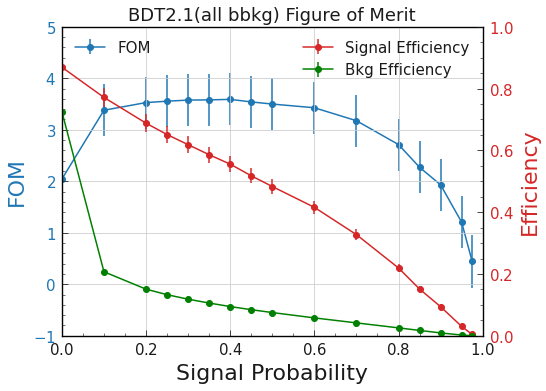

In [29]:
sig_tot = len(sig_D_tau_nu)
bkg_tot = len(df_all.query('isSignal == 0'))
cut = [0,0.1,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.6,0.7,0.8,0.85,0.9,0.95,0.975]
BDT2_FOM = []
BDT2_FOM_err = []
BDT2_sigEff = []
BDT2_sigEff_err = []
BDT2_bkgEff = []
BDT2_bkgEff_err = []
for i in cut:
    sig = len(sig_D_tau_nu.query(f"MVA1_output>0.4 and MVA2_1_output>{i}"))
    bkg = len(df.query(f"isSignal == 0 and MVA1_output>0.4 and MVA2_1_output>{i}"))
    tot = sig+bkg
    tot_err = np.sqrt(tot)
    FOM = sig / tot_err
    FOM_err = np.sqrt( (tot_err - FOM/2)**2 /tot**2 * sig + bkg**3/(4*tot**3) + 9*bkg**2*np.sqrt(sig*bkg)/(4*tot**5) )
    BDT2_FOM.append(FOM)
    BDT2_FOM_err.append(FOM_err)
    
    sigEff = sig / sig_tot
    sigEff_err = sigEff * np.sqrt(1/sig + 1/sig_tot)
    bkgEff = bkg / bkg_tot
    bkgEff_err = bkgEff * np.sqrt(1/bkg + 1/bkg_tot)
    BDT2_sigEff.append(sigEff)
    BDT2_sigEff_err.append(sigEff_err)
    BDT2_bkgEff.append(bkgEff)
    BDT2_bkgEff_err.append(bkgEff_err)

#plt.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='BDT2')
#plt.errorbar(x=cut, y=efficiency_2, yerr=efficiency_2_err,marker='v',label='$\Gamma=m_N$')
#plt.grid()
#plt.legend()
#plt.yscale('log')
#plt.xlim(0,1)
#plt.ylim(bottom=0)


fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Signal Probability')
ax1.set_ylabel('FOM', color=color)
ax1.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='FOM',color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Efficiency', color=color)  # we already handled the x-label with ax1
ax2.errorbar(x=cut, y=BDT2_sigEff, yerr=BDT2_sigEff_err,marker='o',label='Signal Efficiency',color=color)
ax2.errorbar(x=cut, y=BDT2_bkgEff, yerr=BDT2_bkgEff_err,marker='o',label='Bkg Efficiency',color='green')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend()

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('BDT2.1(all bbkg) Figure of Merit')
plt.xlim(0,1)
plt.ylim(bottom=0)
plt.show()

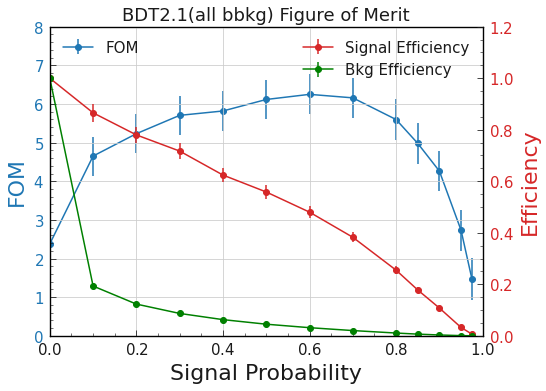

In [58]:
sig_tot = len(sig_D_tau_nu)
bkg_tot = len(df.query('isSignal == 0'))
cut = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.85,0.9,0.95,0.975]
BDT2_FOM = []
BDT2_FOM_err = []
BDT2_sigEff = []
BDT2_sigEff_err = []
BDT2_bkgEff = []
BDT2_bkgEff_err = []
for i in cut:
    sig = len(sig_D_tau_nu.query(f"MVA2_1_output>{i}"))
    bkg = len(df.query(f"isSignal == 0 and MVA2_1_output>{i}"))
    tot = sig+bkg
    tot_err = np.sqrt(tot)
    FOM = sig / tot_err
    FOM_err = np.sqrt( (tot_err - FOM/2)**2 /tot**2 * sig + bkg**3/(4*tot**3) + 9*bkg**2*np.sqrt(sig*bkg)/(4*tot**5) )
    BDT2_FOM.append(FOM)
    BDT2_FOM_err.append(FOM_err)
    
    sigEff = sig / sig_tot
    sigEff_err = sigEff * np.sqrt(1/sig + 1/sig_tot)
    bkgEff = bkg / bkg_tot
    bkgEff_err = bkgEff * np.sqrt(1/bkg + 1/bkg_tot)
    BDT2_sigEff.append(sigEff)
    BDT2_sigEff_err.append(sigEff_err)
    BDT2_bkgEff.append(bkgEff)
    BDT2_bkgEff_err.append(bkgEff_err)

#plt.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='BDT2')
#plt.errorbar(x=cut, y=efficiency_2, yerr=efficiency_2_err,marker='v',label='$\Gamma=m_N$')
#plt.grid()
#plt.legend()
#plt.yscale('log')
#plt.xlim(0,1)
#plt.ylim(bottom=0)


fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Signal Probability')
ax1.set_ylabel('FOM', color=color)
ax1.errorbar(x=cut, y=BDT2_FOM, yerr=BDT2_FOM_err,marker='o',label='FOM',color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Efficiency', color=color)  # we already handled the x-label with ax1
ax2.errorbar(x=cut, y=BDT2_sigEff, yerr=BDT2_sigEff_err,marker='o',label='Signal Efficiency',color=color)
ax2.errorbar(x=cut, y=BDT2_bkgEff, yerr=BDT2_bkgEff_err,marker='o',label='Bkg Efficiency',color='green')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend()

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('BDT2.1(all bbkg) Figure of Merit')
plt.xlim(0,1)
plt.ylim(bottom=0)
plt.show()

### Final Cuts and Best Candidate Selection

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
plt.style.use('belle2')
import numpy as np
import pdg
import root_pandas
import pandas
import decayHash
from decayHash import DecayHashMap

df_all = root_pandas.read_root('exp16_17_e_all_withMVA2.root', key='B0')
#decayhash='../exp16_17_e_idglobal_bb_2/hashmap_generic_MC_e.root'
#hashmap2 = DecayHashMap(decayhash, removeRadiativeGammaFlag=True)

Welcome to JupyROOT 6.24/00


In [2]:
df_bestSelected=df_all.loc[df_all.groupby(['__experiment__','__run__','__event__','__production__']).B_D_ReChi2.idxmin()]

In [3]:
# Signal components
sig_D_e_nu=df_bestSelected.query('DecayMode=="sig_D_e_nu" and B0_mcErrors<32 and abs(B0_mcPDG)==511 and abs(D_mcPDG)==411').copy()
sig_D_mu_nu=df_bestSelected.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<32').copy()
sig_D_tau_nu=df_bestSelected.query('DecayMode=="sig_D_tau_nu" and B0_mcErrors<32').copy()
all_Dst_e_nu=df_bestSelected.query('DecayMode=="all_Dst_e_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_mu_nu=df_bestSelected.query('DecayMode=="all_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dst_tau_nu=df_bestSelected.query('DecayMode=="all_Dst_tau_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
all_Dstst_e_nu=df_bestSelected.query('DecayMode=="all_Dstst_e_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_mu_nu=df_bestSelected.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()
all_Dstst_tau_nu=df_bestSelected.query('DecayMode=="all_Dstst_tau_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

# Bkg components
bkg_fakeD = df_bestSelected.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

# combinatorial where the D and B decay to my signal modes
bkg_combinatorial = df_bestSelected.query('DecayMode!="bkg" and B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
# D and B don't decay to my signal modes but B_reco can be combinatorial
bkg_sigOtherBDTaudecay = df_bestSelected.query('DecayMode=="bkg" and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()

bkg_recoWrongSideB = df_bestSelected.query('((DecayMode=="sig_D_tau_nu" or DecayMode=="sig_D_e_nu" or DecayMode=="sig_D_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 32<=B0_mcErrors<64 and B0_isContinuumEvent!=1) or \
    ((DecayMode=="all_Dstst_tau_nu" or DecayMode=="all_Dstst_e_nu" or DecayMode=="all_Dstst_mu_nu" or \
        DecayMode=="all_Dst_tau_nu" or DecayMode=="all_Dst_e_nu" or DecayMode=="all_Dst_mu_nu") and \
        abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 8<=B0_mcErrors<16 and B0_isContinuumEvent!=1) or \
        (DecayMode!="bkg" and abs(B0_mcPDG)!=300553 and abs(D_mcPDG)==411 and 64<=B0_mcErrors<512 and B0_isContinuumEvent!=1)').copy()
# reconstructing the wrong side: 1. semileptonic in both side; 
#                                2. reco the hadronic B_tag, B_sig other_D_decay;
#                                3. reco B_tag -> D+ D_s, D_s -> tau nu

bkg_recoFakeTracksClusters = df_bestSelected.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
bkg_continuum = df_bestSelected.query('B0_isContinuumEvent==1').copy()


def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

kwarg={'bins':50, 'histtype':'step','lw':2}

    
def plot_projection(cut,variable):
    (counts1, bins1) = np.histogram(sig_D_tau_nu.query(cut)[variable], bins=50)
    (counts2, bins2) = np.histogram(all_Dst_tau_nu.query(cut)[variable], bins=50)
    factor = 50
    plt.hist(bins1[:-1], bins1, weights=factor*counts1,label=f'D_tau_nu \n{statistics(sig_D_tau_nu.query(cut)[variable])}',alpha=0.6)
    sig_D_e_nu.query(cut)[variable].hist(label=f'D_e_nu \n{statistics(sig_D_e_nu.query(cut)[variable])}',**kwarg)
    
    plt.hist(bins2[:-1], bins2, weights=factor*counts2,label=f'Dst_tau_nu \n{statistics(all_Dst_tau_nu.query(cut)[variable])}',alpha=0.6,histtype='step',lw=2)
    all_Dst_e_nu.query(cut)[variable].hist(label=f'Dst_e_nu \n{statistics(all_Dst_e_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_tau_nu.query(cut)[variable].hist(label=f'all_Dstst_tau_nu \n{statistics(all_Dstst_tau_nu.query(cut)[variable])}',**kwarg)
    all_Dstst_e_nu.query(cut)[variable].hist(label=f'all_Dstst_e_nu \n{statistics(all_Dstst_e_nu.query(cut)[variable])}',**kwarg)
    bkg_fakeD.query(cut)[variable].hist(label=f'bkg_fakeD \n{statistics(bkg_fakeD.query(cut)[variable])}',**kwarg)
    bkg_combinatorial.query(cut)[variable].hist(label=f'bkg_combinatorial \n{statistics(bkg_combinatorial.query(cut)[variable])}',**kwarg)
    bkg_sigOtherBDTaudecay.query(cut)[variable].hist(label=f'bkg_sigOtherBDTaudecay \n{statistics(bkg_sigOtherBDTaudecay.query(cut)[variable])}',**kwarg)
    bkg_recoWrongSideB.query(cut)[variable].hist(label=f'bkg_recoWrongSideB \n{statistics(bkg_recoWrongSideB.query(cut)[variable])}',**kwarg)
    bkg_recoFakeTracksClusters.query(cut)[variable].hist(label=f'bkg_recoFakeTracksClusters \n{statistics(bkg_recoFakeTracksClusters.query(cut)[variable])}',**kwarg)
    bkg_continuum.query(cut)[variable].hist(label=f'bkg_continuum \n{statistics(bkg_continuum.query(cut)[variable])}',**kwarg)
    plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)

In [4]:
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)

len(bkg_fakeD)+len(sig_D_e_nu)+len(sig_D_mu_nu)+len(sig_D_tau_nu)+len(all_Dst_e_nu)+len(all_Dst_mu_nu)+len(all_Dst_tau_nu)+len(all_Dstst_e_nu)+len(all_Dstst_mu_nu)+len(all_Dstst_tau_nu)+len(bkg_combinatorial)+len(bkg_sigOtherBDTaudecay)+len(bkg_recoWrongSideB)+len(bkg_recoFakeTracksClusters)+len(bkg_continuum)==len(df_bestSelected)

True

In [25]:
pandas.set_option('display.max_rows', None)
cut = 'MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26'
bkg_sigOtherBDTaudecay.query(cut).D_mcPDG.value_counts()

 411.0    1228
-411.0     913
Name: D_mcPDG, dtype: int64

In [ ]:
cut='MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26'
candidate12 = bkg_sigOtherBDTaudecay.query(cut).iloc[6][['B0_DecayHash', "B0_DecayHashEx"]].values

# print the original decay as simulated in MC with removed Bremsstrahlung gammas
print("Monte Carlo Decay with removed Bremsstrahlung gammas: ")
org2 = hashmap2.get_original_decay(*candidate12)
print(org2.to_string())

In [ ]:
plot_projection('MVA1_5_output>0.35', 'B0_CMS_p')
plt.xlabel("CMS momentum")
plt.ylabel('# of counts per bin')
plt.title('signal side B momentum');
#plt.xlim(-10,10)

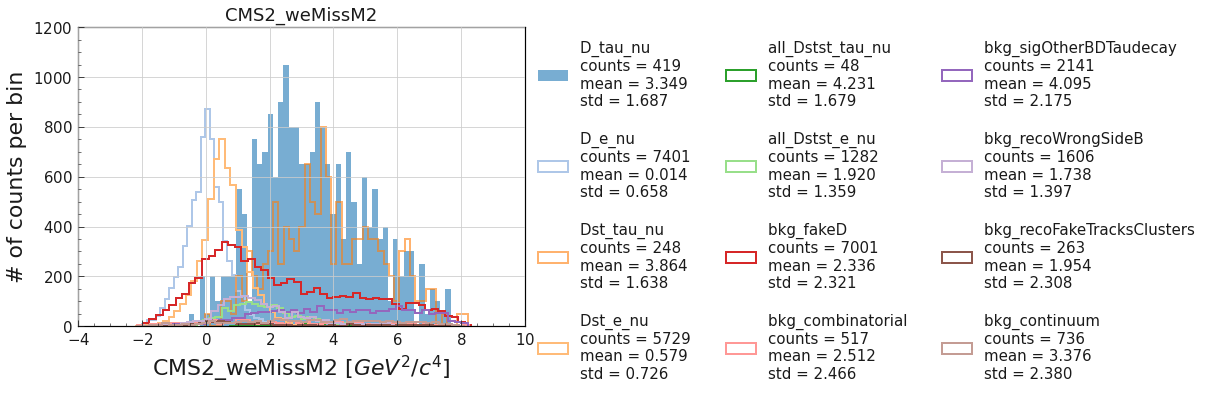

In [12]:
plot_projection('MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26', 'B0_CMS2_weMissM2')
plt.xlabel("CMS2_weMissM2 $[GeV^2/c^4]$")
plt.ylabel('# of counts per bin')
plt.title('CMS2_weMissM2');
#plt.xlim(-10,10)

In [ ]:
import decayHash
from decayHash import DecayHashMap
import ROOT
decayhash='../exp16_17_e_idglobal_bb_1/hashmap_generic_MC_e.root'

hashmap2 = DecayHashMap(decayhash, removeRadiativeGammaFlag=True)
cut='MVA2_1_output>0.6 and B0_roeMbc_my_mask>5.26'
candidate12 = bkg_sigOtherBDTaudecay.query(cut).iloc[6][['B0_DecayHash', "B0_DecayHashEx"]].values

# print the original decay as simulated in MC with removed Bremsstrahlung gammas
print("Monte Carlo Decay with removed Bremsstrahlung gammas: ")
org2 = hashmap2.get_original_decay(*candidate12)
print(org2.to_string())

Monte Carlo Decay with removed Bremsstrahlung gammas: 


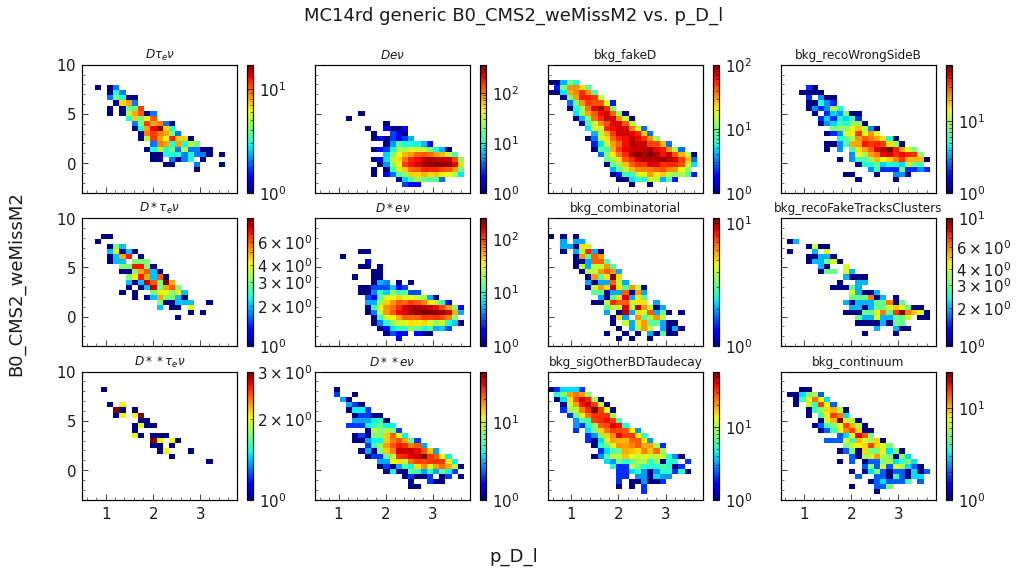

In [37]:
name_list = [r'$D\tau_e\nu$',r'$D*\tau_e\nu$',r'$D**\tau_e\nu$',
             r'$De\nu$',r'$D*e\nu$',r'$D**e\nu$',
             'bkg_fakeD','bkg_combinatorial',
             'bkg_sigOtherBDTaudecay','bkg_recoWrongSideB',
             'bkg_recoFakeTracksClusters','bkg_continuum']
df_list = [sig_D_tau_nu,all_Dst_tau_nu,all_Dstst_tau_nu, 
           sig_D_e_nu,all_Dst_e_nu,all_Dstst_e_nu, 
           bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
           bkg_recoWrongSideB,bkg_recoFakeTracksClusters, bkg_continuum]   
    
    
df_dict = dict(zip(name_list, df_list))

cuts='MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26'

variable_y = 'B0_CMS2_weMissM2'
variable_x = 'p_D_l'

n_rows,n_cols = [3,4]
fig,ax=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
fig.suptitle(f'MC14rd generic {variable_y} vs. {variable_x}')
fig.supxlabel(f'{variable_x}')
fig.supylabel(f'{variable_y}',x=0.06)
k=0
for j in range(n_cols):
    for i in range(n_rows):
        counts, xedges, yedges, im = ax[i,j].hist2d(df_dict[name_list[k]].query(cuts)[variable_x],
                                                    df_dict[name_list[k]].query(cuts)[variable_y],
                                                    range=[[0.5,3.8],[-3,10]],bins=25,cmap='jet',
                                                    norm=colors.LogNorm())
        ax[i,j].set_title(name_list[k],fontsize=12)
        fig.colorbar(im,ax=ax[i,j])
        k+=1

#plt.xlabel('$p_{D}+p_{l}\ [GeV/c]$')
#plt.ylabel('$M_{miss}^2\ [GeV^2/c^4]$')

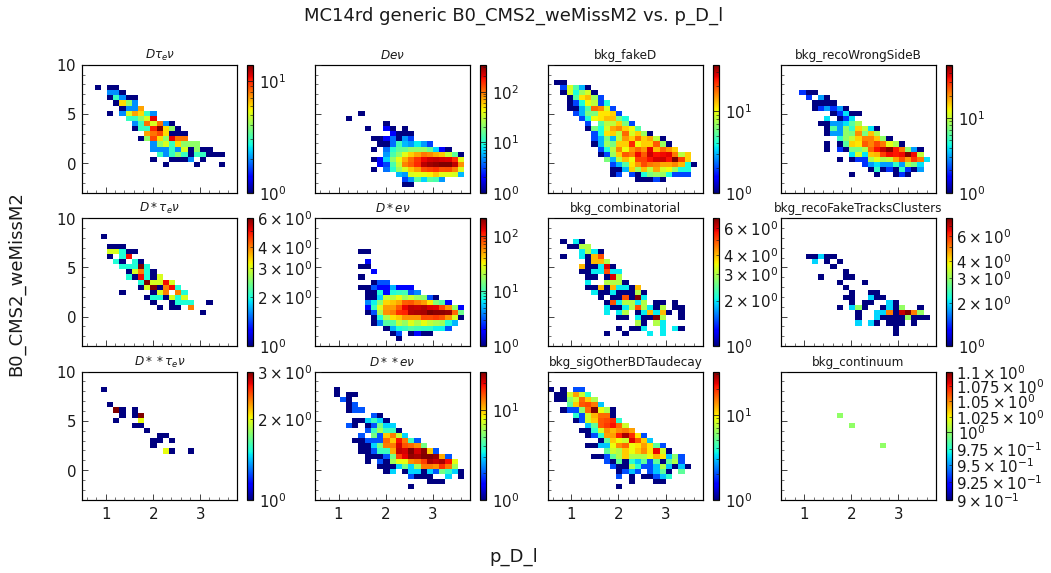

In [14]:
name_list = [r'$D\tau_e\nu$',r'$D*\tau_e\nu$',r'$D**\tau_e\nu$',
             r'$De\nu$',r'$D*e\nu$',r'$D**e\nu$',
             'bkg_fakeD','bkg_combinatorial',
             'bkg_sigOtherBDTaudecay','bkg_recoWrongSideB',
             'bkg_recoFakeTracksClusters','bkg_continuum']
df_list = [sig_D_tau_nu,all_Dst_tau_nu,all_Dstst_tau_nu, 
           sig_D_e_nu,all_Dst_e_nu,all_Dstst_e_nu, 
           bkg_fakeD,bkg_combinatorial,bkg_sigOtherBDTaudecay,
           bkg_recoWrongSideB,bkg_recoFakeTracksClusters, bkg_continuum]   
    
    
df_dict = dict(zip(name_list, df_list))

cuts='MVA2_1_output>0.6 and B0_roeMbc_my_mask>5.26'

variable_y = 'B0_CMS2_weMissM2'
variable_x = 'p_D_l'

n_rows,n_cols = [3,4]
fig,ax=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
fig.suptitle(f'MC14rd generic {variable_y} vs. {variable_x}')
fig.supxlabel(f'{variable_x}')
fig.supylabel(f'{variable_y}',x=0.06)
k=0
for j in range(n_cols):
    for i in range(n_rows):
        counts, xedges, yedges, im = ax[i,j].hist2d(df_dict[name_list[k]].query(cuts)[variable_x],
                                                    df_dict[name_list[k]].query(cuts)[variable_y],
                                                    range=[[0.5,3.8],[-3,10]],bins=25,cmap='jet',
                                                    norm=colors.LogNorm())
        ax[i,j].set_title(name_list[k],fontsize=12)
        fig.colorbar(im,ax=ax[i,j])
        k+=1

#plt.xlabel('$p_{D}+p_{l}\ [GeV/c]$')
#plt.ylabel('$M_{miss}^2\ [GeV^2/c^4]$')

## 1-d Fitting

In [6]:
import pyhf
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

pyhf.set_backend('numpy','minuit')

In [9]:
cut='MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26'
bins = np.linspace(-3.5, 4, 25)
variable = 'B0_CMS2_weMissM2'

(counts, bins) = np.histogram(sig_D_e_nu.query(cut)[variable], bins=bins)

In [10]:
template = np.array([  2,   1,   4,   8,  25,  52, 102, 151, 246, 418, 736, 936, 470,
       229, 125,  58,  32,   9,   6,   6,   5,   5,   4,   5])
template_err = np.sqrt(template)
data = counts

In [11]:
samples = [
    {
        "name": "sample1",
        "data": list(template),
        "modifiers": [
            # first modifier: normalization factor
            {"name": "mu1", "type": "normfactor", "data" : None},
            # second modifier: uncorrelated uncertainties per bin
            {
                "name": "uncorrelated_uncertainties",
                "type": "shapesys", # staterror
                "data" : list(template_err)
            }
        ],
    },
]
spec = {"channels" : [{"name" : "singlechannel", "samples" : samples}]}
model_uncorr = pyhf.Model(spec, poi_name=None)

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.

Exception in thread Exception in threading.excepthook:Exception ignored in thread started byException ignored in sys.unraisablehook

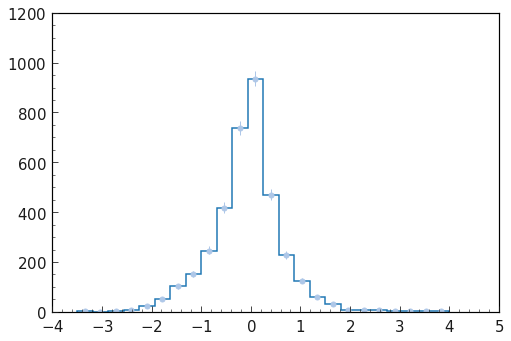

In [22]:
initial_parameters = model_uncorr.config.suggested_init()
hep.histplot(model_uncorr.expected_auxdata(initial_parameters), bins)
hep.histplot(model_uncorr.config.auxdata, bins, histtype="errorbar")
print(initial_parameters)

In [24]:
import ipywidgets as widgets

# You don't need to understand right now what is happening in this code cell, first focus on the application

sliders_gamma = {
    f"gamma{i}" : widgets.FloatSlider(
        1.0,
        min=0.99,
        max=1.01,
        orientation="vertical",
        continuous_update=False,
        description=f"γ{i}",
        layout=widgets.Layout(width='25px')
    )
    for i in range(1, 25)
}

slider_mu = widgets.FloatSlider(
    1.0, min=0.1, max=10.0, description="Norm factor", continuous_update=False
)

def plot(mu, **kwargs):
    fig, axs = plt.subplots(ncols=2, figsize=(20, 5))

    parameters = model_uncorr.config.suggested_init()
    
    parameters[0] = mu
    
    for k in kwargs:
        i = int(k.replace("gamma", ""))
        parameters[i] = kwargs[k]

    hep.histplot(model_uncorr.expected_actualdata(parameters), bins, ax=axs[0],label='fitted_template')
    hep.histplot(data, bins, yerr=np.sqrt(data), histtype="errorbar", color="black", ax=axs[0],label='data')
    hep.histplot(model_uncorr.expected_auxdata(parameters), bins, ax=axs[1],label='fitted_template')
    param_set = model_uncorr.config.param_set("uncorrelated_uncertainties")
    hep.histplot(
        model_uncorr.config.auxdata,
        bins,
        yerr=model_uncorr.config.auxdata * np.array(param_set.width()),
        histtype="errorbar", color="red",
        ax=axs[1],label='data'
    )
    axs[0].set_title("Actual data")
    axs[0].legend()
    axs[1].set_title("Auxiliary data")
    axs[1].legend()
    
    print(
        "Negative Log-Likelihood: "
        f"{- model_uncorr.logpdf(parameters, np.concatenate([data, model_uncorr.config.auxdata]))[0]:.3f}"
    )
    
interactive_plot = widgets.interactive_output(plot, dict(sliders_gamma, mu=slider_mu))
interactive_plot.layout.height = "300px"

def fit(b):
    parameters = pyhf.infer.mle.fit(np.concatenate([data, model_uncorr.config.auxdata]), model_uncorr)
    # parameters_1bin, correlations_1bin = pyhf.infer.mle.fit(data_1bin, model_1bin, return_uncertainties=True, return_correlations=True)
    slider_mu.value = parameters[0]
    for k in sliders_gamma:
        i = int(k.replace("gamma", ""))
        sliders_gamma[k].value = parameters[i]
        
button = widgets.Button(description="Fit")
button.on_click(fit)

display(
    slider_mu,
    widgets.HBox(
        [widgets.HBox(layout=widgets.Layout(width='5px'))]
        + [sliders_gamma[f"gamma{i}"] for i in range(1, 25)]
    ),
    button,
    interactive_plot
)

FloatSlider(value=1.0, continuous_update=False, description='Norm factor', max=10.0, min=0.1)

Button(description='Fit', style=ButtonStyle())

Output(layout=Layout(height='300px'))

In [25]:
parameters, correlations = pyhf.infer.mle.fit(np.concatenate([data, model_uncorr.config.auxdata]), model_uncorr, return_uncertainties=True, return_correlations=True)

In [26]:
parameters

array([2.03521252, 0.32950718, 0.32952584, 0.32947675, 0.32947057,
       0.4348967 , 0.62724986, 0.70415368, 0.96876075, 1.01384637,
       1.01046839, 0.94049739, 0.96375809, 1.14051162, 1.23298047,
       1.21507124, 1.13609465, 1.02957586, 1.35447224, 0.87858303,
       0.82369015, 0.5930519 , 0.52714355, 0.90599599, 0.32945603])

# 2-d fitting

In [22]:
cut='MVA1_output>0.4 and MVA2_1_output>0.2 and B0_roeMbc_my_mask>5.26'
xedges = np.linspace(1, 4, 15)
yedges = np.linspace(-3.5, 4, 20)
variable_x = 'p_D_l'
variable_y = 'B0_CMS2_weMissM2'

(counts2d, xedges, yedges) = np.histogram2d(sig_D_e_nu.query(cut)[variable_x], 
                                            sig_D_e_nu.query(cut)[variable_y],
                                            bins=[xedges,yedges])

In [76]:
template2d = np.array([[  1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   3.,   1.,
          1.,   1.,   1.,   1.,   3.,   2.,   2.,   1.],
       [  1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   5.,   1.,   6.,
          1.,   1.,   2.,   1.,   3.,   2.,   1.,   2.],
       [  1.,   1.,   3.,   1.,   1.,   6.,   5.,   9.,  14.,  12.,  11.,
          3.,   5.,   2.,   3.,   2.,   2.,   4.,   4.],
       [  1.,   1.,   1.,   2.,   2.,   5.,  16.,  24.,  37.,  47.,  26.,
         24.,  12.,  10.,   5.,   3.,   3.,   1.,   3.],
       [  1.,   1.,   1.,   2.,  13.,  19.,  23.,  48.,  76.,  68.,  47.,
         37.,  18.,   7.,   2.,   1.,   3.,   1.,   1.],
       [  2.,   2.,   8.,   6.,  16.,  33.,  53.,  80., 124., 111.,  76.,
         40.,  14.,   6.,   2.,   2.,   1.,   1.,   1.],
       [  2.,   1.,   1.,  11.,  16.,  31.,  66.,  93., 143., 137.,  75.,
         36.,  14.,   1.,   1.,   1.,   1.,   1.,   1.],
       [  1.,   1.,   2.,   9.,  15.,  31.,  40.,  94., 156., 172.,  50.,
         19.,   2.,   3.,   1.,   1.,   1.,   1.,   1.],
       [  2.,   1.,   1.,   5.,   8.,  17.,  34.,  65., 170., 139.,  42.,
          4.,   1.,   1.,   1.,   1.,   1.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   4.,  13.,  26.,  60., 144., 104.,  18.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   2.,   6.,  17.,  37., 116.,  57.,   2.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.]]).T
template2d_err = np.sqrt(template2d.flat)
data = counts2d.T

In [77]:
samples = [
    {
        "name": "sample1",
        "data": list(template2d.flat),
        "modifiers": [
            # first modifier: normalization factor
            {"name": "mu1", "type": "normfactor", "data" : None},
            # second modifier: uncorrelated uncertainties per bin
#            {
#                "name": "uncorrelated_uncertainties",
#                "type": "shapesys", # staterror
#                "data" : list(template2d_err)
#            }
        ],
    },
]
spec = {"channels" : [{"name" : "singlechannel", "samples" : samples}]}
model_uncorr = pyhf.Model(spec, poi_name=None)

[1.0]


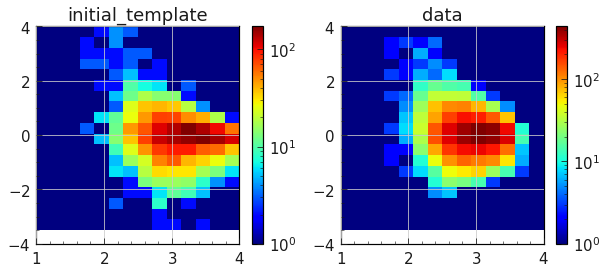

In [78]:
initial_parameters = model_uncorr.config.suggested_init()

fig,axs=plt.subplots(ncols=2,figsize=(10,4))
X, Y = np.meshgrid(xedges, yedges)
im0=axs[0].pcolormesh(X, Y, template2d, cmap='jet', norm=colors.LogNorm())
im1=axs[1].pcolormesh(X, Y, data+1, cmap='jet', norm=colors.LogNorm())

#axs[0].set_aspect('equal')
#axs[1].set_aspect('equal')
axs[0].set_title('initial_template')
axs[1].set_title('data')
axs[0].grid()
axs[1].grid()
fig.colorbar(im0, ax=axs[0])
fig.colorbar(im1, ax=axs[1])

print(initial_parameters)

In [74]:
model_uncorr.expected_data(initial_parameters).reshape(template2d.shape)

array([[  0.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   2.,   2.,   1.,
          2.,   1.,   1.],
       [  0.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   2.,   1.,   1.,
          1.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   1.,   3.,   1.,   1.,   8.,   1.,   2.,
          1.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   1.,   1.,   2.,   2.,   6.,  11.,   9.,
          5.,   1.,   1.],
       [  1.,   1.,   1.,   1.,   1.,   1.,   2.,  13.,  16.,  16.,  15.,
          8.,   4.,   2.],
       [  1.,   1.,   1.,   1.,   1.,   6.,   5.,  19.,  33.,  31.,  31.,
         17.,  13.,   6.],
       [  1.,   1.,   1.,   1.,   1.,   5.,  16.,  23.,  53.,  66.,  40.,
         34.,  26.,  17.],
       [  1.,   1.,   1.,   1.,   1.,   9.,  24.,  48.,  80.,  93.,  94.,
         65.,  60.,  37.],
       [  1.,   1.,   1.,   1.,   5.,  14.,  37.,  76., 124., 143., 156.,
        170., 144., 116.],
       [  1.,   1.,   1.,   3.,   1.,  12.,  47.,  68., 111., 137., 172.,
        139., 104

In [81]:
import ipywidgets as widgets

slider_mu = widgets.FloatSlider(
    1.0, min=0.1, max=10.0, description="Norm factor", continuous_update=False
)

def plot(mu, **kwargs):
    parameters = model_uncorr.config.suggested_init()
    parameters[0] = mu
        
    fig, axs = plt.subplots(ncols=2,figsize=(10,4))
    X, Y = np.meshgrid(xedges, yedges)
    im0=axs[0].pcolormesh(X, Y,
                          model_uncorr.expected_data(parameters).reshape(template2d.shape),
                          cmap='jet', norm=colors.LogNorm())
    im1=axs[1].pcolormesh(X, Y, data+1, cmap='jet', norm=colors.LogNorm())

    #axs[0].set_aspect('equal')
    #axs[1].set_aspect('equal')
    axs[0].set_title('initial_template')
    axs[1].set_title('data')
    axs[0].grid()
    axs[1].grid()
    fig.colorbar(im0, ax=axs[0])
    fig.colorbar(im1, ax=axs[1])

    print(
        "Negative Log-Likelihood: "
        f"{- model_uncorr.logpdf(parameters, np.concatenate([data.flat]))[0]:.3f}"
    )
    
interactive_plot = widgets.interactive_output(plot, dict(mu=slider_mu))
interactive_plot.layout.height = "300px"

def fit(b):
    parameters = pyhf.infer.mle.fit(np.concatenate([(data+1).flat]), model_uncorr, return_uncertainties=True)
    # parameters_1bin, correlations_1bin = pyhf.infer.mle.fit(data_1bin, model_1bin, return_uncertainties=True, return_correlations=True)
    slider_mu.value = parameters[0][0]
    print(f'uncertainty: {parameters[0][1]}')
        
button = widgets.Button(description="Fit")
button.on_click(fit)

display(
    button,
    interactive_plot,
    slider_mu,
)

Button(description='Fit', style=ButtonStyle())

Output(layout=Layout(height='300px'))

FloatSlider(value=1.0, continuous_update=False, description='Norm factor', max=10.0, min=0.1)

uncertainty: 0.023462047833622268


## More components 2d

In [ ]:
    bkg_fakeD.query(cut)[variable].hist(label=f'bkg_fakeD \n{statistics(bkg_fakeD.query(cut)[variable])}',**kwarg)
    bkg_combinatorial.query(cut)[variable].hist(label=f'bkg_combinatorial \n{statistics(bkg_combinatorial.query(cut)[variable])}',**kwarg)
    bkg_sigOtherBDTaudecay.query(cut)[variable].hist(label=f'bkg_sigOtherBDTaudecay \n{statistics(bkg_sigOtherBDTaudecay.query(cut)[variable])}',**kwarg)
    bkg_recoWrongSideB.query(cut)[variable].hist(label=f'bkg_recoWrongSideB \n{statistics(bkg_recoWrongSideB.query(cut)[variable])}',**kwarg)
    bkg_recoFakeTracksClusters.query(cut)[variable].hist(label=f'bkg_recoFakeTracksClusters \n{statistics(bkg_recoFakeTracksClusters.query(cut)[variable])}',**kwarg)
    bkg_continuum.query(cut)[variable].hist

In [ ]:
bkg_sample = bkg_fakeD

cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
xedges = np.linspace(0.5, 4, 15)
yedges = np.linspace(-4, 10, 25)
variable_x = 'p_D_l'
variable_y = 'B0_CMS2_weMissM2'

(counts, xedges, yedges) = np.histogram2d(bkg_sample.query(cut)[variable_x], 
                                          bkg_sample.query(cut)[variable_y],
                                          bins=[xedges, yedges])
counts = counts.T + 0.01

In [ ]:
import json

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC_ROEx1/2d_2channels_workspace.json'
with open(workspace_file, 'r+') as f:
    data = json.load(f)
    data['channels'][0]['samples'][6]['name'] = 'bkg_fake_D'
    data['channels'][0]['samples'][6]['data'] = counts.ravel().tolist()
    # counts.ravel()/.reshape(-1) returns a view, counts.flatten() returns a copy (slower)
    f.seek(0)        # <--- should reset file position to the beginning.
    json.dump(data, f, indent=4)
    f.truncate()     # remove remaining part

In [5]:
electron_mode_samples = pandas.concat([sig_D_e_nu, sig_D_tau_nu, all_Dst_e_nu,
                                       all_Dst_tau_nu, all_Dstst_e_nu, all_Dstst_tau_nu],
                                      axis=0)
cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
electron_mode_samples = electron_mode_samples.query(cut)
len(electron_mode_samples)

15127

In [9]:
len(sig_D_mu_nu)+len(all_Dst_mu_nu)#+len(all_Dstst_mu_nu)

148

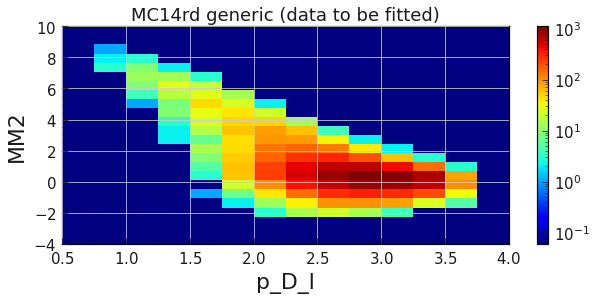

In [6]:
import pyhf
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

pyhf.set_backend('numpy','minuit')

sig_sample = electron_mode_samples

cut='B0_roeMbc_my_mask>5.26 and MVA1_output>0.4 and MVA2_1_output>0.2'
xedges = np.linspace(0.5, 4, 15)
yedges = np.linspace(-4, 10, 25)
variable_x = 'p_D_l'
variable_y = 'B0_CMS2_weMissM2'

(counts, xedges, yedges) = np.histogram2d(sig_sample.query(cut)[variable_x], 
                                          sig_sample.query(cut)[variable_y],
                                          bins=[xedges, yedges])
counts = counts.T + 0.06
fig,axs=plt.subplots(ncols=1,figsize=(10,4))
X, Y = np.meshgrid(xedges, yedges)
im=axs.pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())
axs.set_title('MC14rd generic (data to be fitted)')
axs.set_ylabel('MM2')
axs.set_xlabel('p_D_l')
axs.grid()
fig.colorbar(im)

In [7]:
import json

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC_ROEx1/2d_2channels_workspace.json'
with open(workspace_file, 'r+') as work_f:
    spec = json.load(work_f)
#    spec['observations'][0]['name'] = 'electron mode'
#    spec['observations'][0]['data'] = counts.ravel().tolist()
    spec_1 = {'channels': spec['channels']}
    model_1 = pyhf.Model(spec_1, poi_name=None)
model_1.spec
#workspace = pyhf.Workspace(spec)
#workspace

{'channels': [{'name': 'electron mode',
   'samples': [{'name': 'D_tau_nu',
     'data': [0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      1.01,
      0.01,
      2.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
      0.01,
    

In [9]:
import ipywidgets as widgets

sliders_norm = {
    f"n{i}" : widgets.FloatSlider(
        1.0,
        min=0.1,
        max=10.0,
        orientation="vertical",
        continuous_update=False,
        description=f"n{i}",
        layout=widgets.Layout(width='35px')
    )
    for i in range(0, 6)
}

def plot(**kwargs):
    parameters = model_1.config.suggested_init()
    
    for k in kwargs:
        i = int(k.replace("n", ""))
        parameters[i] = kwargs[k]
        
    fig, axs = plt.subplots(ncols=2,figsize=(14,4))
    X, Y = np.meshgrid(xedges, yedges)
    im0=axs[0].pcolormesh(X, Y,
                          model_1.expected_data(parameters).reshape(counts.shape),
                          cmap='jet', norm=colors.LogNorm())
    im1=axs[1].pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())

    #axs[0].set_aspect('equal')
    #axs[1].set_aspect('equal')
    axs[0].set_title('initial_template')
    axs[1].set_title('data')
    axs[0].grid()
    axs[1].grid()
    fig.colorbar(im0, ax=axs[0])
    fig.colorbar(im1, ax=axs[1])

    print(
        "Negative Log-Likelihood: "
        f"{- model_1.logpdf(parameters, np.concatenate([counts.flat]))[0]:.3f}"
    )
    
interactive_plot = widgets.interactive_output(plot, dict(sliders_norm))
interactive_plot.layout.height = "300px"

def fit(b):
    parameters = pyhf.infer.mle.fit(np.concatenate([counts.flat]), model_1, return_uncertainties=False)
    # parameters_1bin, correlations_1bin = pyhf.infer.mle.fit(data_1bin, model_1bin, return_uncertainties=True, return_correlations=True)
    for k in sliders_norm:
        i = int(k.replace("n", ""))
        sliders_norm[k].value = parameters[i]
#    print(f'uncertainty: {parameters[0][1]}')
        
button = widgets.Button(description="Fit")
button.on_click(fit)

display(
    button,
    interactive_plot,
    widgets.HBox(
        [widgets.HBox(layout=widgets.Layout(width='45px'))]
        + [sliders_norm[f"n{i}"] for i in range(0, 6)]
    ),
)

Button(description='Fit', style=ButtonStyle())

Output(layout=Layout(height='300px'))